# 15b - Looking at the targets: what they fire on, and who they fire on

Notebook 15 built the four labels and checked they were not broken. It did not really *look* at them.
This one does, and it exists for a specific reason: I need a handful of figures for the final report,
and I need to be able to explain to the team why we are shipping four separate indices instead of one
"good prospect" score.

Nothing here changes any definition or writes anything to disk. It reads
`data/processed/labels/` and `data/processed/model_matrix/` and plots them. Four sections:

1. **Label anatomy.** What each label fires on, how often, and whether that rate is stable over time.
2. **Overlap.** Do the four labels hit the same companies, or different ones? This is the argument
   for four indices rather than one.
3. **Feature separation.** Which features actually separate positives from negatives, per target.
   A preview of what the SHAP plots in step 6 should end up saying, computed without a model.
4. **Who the positives are.** Base rate by sector, size, age and region. This is the cut a
   relationship manager reads first: which parts of the book carry each signal.

One thing to keep straight throughout. **Base rates come from `labels/`, which is the full
unsampled population. Feature comparisons come from `model_matrix/`, where negatives are
downsampled 1:10.** Mixing those up would make every rate on this page wrong by an order of
magnitude, so I have kept them in separate sections and said which is which each time.

### The five words I keep using

Writing this out once because I kept having to explain it verbally, and because the words are easy
to nod along to and then get wrong.

- **Origin (`t`).** A month we stand in and pretend it is today. Ours are quarterly: 2023-10,
  2024-01, 2024-04 and so on.
- **Horizon (`H`).** How far forward the label looks. Three months for lending, six for the two
  failure labels, twelve for growth.
- **A row.** One **company at one origin**, not one company. The same company appears at up to
  eleven origins, and each is a separate observation. Everything counted on this page is counted in
  rows unless I say otherwise.
- **A positive.** A row where the thing we care about happened somewhere in `t+1 ... t+H`. Not a
  company that is "risky looking" at `t`. The label is about the future, always.
- **The base rate.** The share of rows that are positive. That is it. "0.34% insolvency" means that
  of all the times a company was observed active at a quarterly origin, 0.34% of those times it
  entered insolvency within the next six months.

### Why the two directories exist, and why negatives are thrown away

`labels/` has every company that was active at each origin: about 1.4 million rows per origin, of
which roughly 0.34% are insolvency positives. That is the real world, so any **rate** has to be
measured there.

`model_matrix/` is the training set, and it is deliberately not the real world. Keeping 1.4 million
negatives to teach a model about 4,000 positives is mostly wasted compute: the 1,300,000th
near-identical dormant micro-company teaches it nothing the first 50,000 did not. So we keep **every
positive** and throw away most negatives, stopping at ten negatives per positive. Insolvency goes
from 13.8 million rows to 520 thousand, about 27 times less to train on, without losing a single
positive.

The price is that the matrix now *looks* like a world where 9% of companies go insolvent. Ranking
survives that untouched, which is why section 3 measures AUC on the matrix quite safely. Rates do
not survive it, and every predicted probability comes out roughly 27 times too high. That is what
the `neg_keep_rate` column is for, and section 3.1 shows the arithmetic that undoes it.

## Setup

In [1]:
import os
import sys
from pathlib import Path

REPO_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(REPO_ROOT))
os.chdir(REPO_ROOT)

import duckdb
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import TwoSlopeNorm

from src.features import panel
from src.models import targets

con = duckdb.connect()
con.execute("PRAGMA disable_progress_bar")
con.execute("PRAGMA threads=6")
con.execute("SET memory_limit='10GB'")
con.execute("SET temp_directory='data/processed/duckdb_tmp'")

LABEL_GLOB = (targets.LABEL_DIR / "**" / "*.parquet").as_posix()
DELTA_GLOB = (panel.DELTA_DIR / "**" / "*.parquet").as_posix()
MATRIX = lambda t: (targets.MATRIX_DIR / t / "**" / "*.parquet").as_posix()

# One colour per target, used everywhere below so the report figures stay consistent.
COLOR = {"lending": "#2c7fb8", "insolvency": "#c0392b",
         "voluntary_exit": "#e08214", "growth": "#31a354"}
NICE = {"lending": "Lending Readiness", "insolvency": "Credit Risk Exposure",
        "voluntary_exit": "Voluntary Exit", "growth": "Growth Signal"}
ORDER = ["lending", "insolvency", "voluntary_exit", "growth"]

plt.rcParams.update({"figure.dpi": 110, "axes.grid": True, "grid.alpha": 0.25,
                     "axes.spines.top": False, "axes.spines.right": False,
                     "font.size": 9})

print("labels :", LABEL_GLOB)
print("matrix :", targets.MATRIX_DIR.as_posix())

labels : data/processed/labels/**/*.parquet
matrix : data/processed/model_matrix


---
## 1. Label anatomy

### 1.1 What each label actually fires on

Worth restating in one table, because "Credit Risk Exposure" and "Voluntary Exit" are both
"the company is in trouble" to a casual reader and they are not remotely the same event.

In [2]:
anatomy = pd.DataFrame([
    {"target": "lending",
     "index": "Lending Readiness",
     "fires when": "Mortgages.NumMortCharges is higher at any month in t+1..t+H",
     "reads as": "took on new secured borrowing"},
    {"target": "insolvency",
     "index": "Credit Risk Exposure",
     "fires when": "status enters liquidation / administration / receivership / voluntary arrangement",
     "reads as": "a genuine credit event"},
    {"target": "voluntary_exit",
     "index": "Voluntary Exit",
     "fires when": "status becomes 'Active - Proposal to Strike off'",
     "reads as": "winding down by choice, revenue going to zero"},
    {"target": "growth",
     "index": "Growth Signal",
     "fires when": "size band moves up the Micro < Small < Medium < Large ladder",
     "reads as": "grew past a filing threshold"},
]).set_index("target")
anatomy["H (months)"] = [targets.TARGETS[t][1] for t in anatomy.index]
anatomy

,index,fires when,reads as,H (months)
target,,,,
lending,Lending Readiness,Mortgages.NumMortCharges is higher at any mont...,took on new secured borrowing,3
insolvency,Credit Risk Exposure,status enters liquidation / administration / r...,a genuine credit event,6
voluntary_exit,Voluntary Exit,status becomes 'Active - Proposal to Strike off',"winding down by choice, revenue going to zero",6
growth,Growth Signal,size band moves up the Micro < Small < Medium ...,grew past a filing threshold,12


### 1.2 How many rows, how many positives

Straight off `labels/`, which is the unsampled population: every company that was **Active at the
origin**, at every quarterly origin. NULL means "cannot say" (the window runs off the end of the
panel, or for growth the company has no size band at `t`), and I count only the non-NULL rows.

In [3]:
totals = pd.concat([
    con.execute(f"""
        SELECT '{t}' AS target,
               count({col})            AS labelled_rows,
               sum({col})              AS positives,
               avg({col}::DOUBLE)      AS base_rate,
               count(DISTINCT CASE WHEN {col} = 1 THEN "CompanyNumber" END) AS distinct_companies,
               count(DISTINCT origin_month) FILTER (WHERE {col} IS NOT NULL) AS origins
        FROM read_parquet('{LABEL_GLOB}')
    """).df()
    for t, (col, _) in targets.TARGETS.items()
], ignore_index=True).set_index("target").loc[ORDER]

totals["base_rate_%"] = (totals["base_rate"] * 100).round(3)
totals.drop(columns="base_rate")

,labelled_rows,positives,distinct_companies,origins,base_rate_%
target,,,,,
lending,15244182,41788.0,32657,11,0.274
insolvency,13846845,47262.0,26481,10,0.341
voluntary_exit,13846845,1083664.0,559931,10,7.826
growth,7213562,150806.0,52617,8,2.091


The spread is the point. Insolvency gives me **47,000 positive rows across 26,000 distinct companies**;
voluntary exit gives me **1.08 million rows across 560,000 companies**, twenty three times as many.
Those are very different modelling problems even though both are six-month horizons, and it is why I
would not dream of blending them into a single "distress" score: the loud label would simply drown
the important one.

The distinct-company column is worth a second look. A company can appear as a positive at several
origins (insolvency at `t` is usually still insolvency at `t+3`), so rows overstate how much
independent information there is. 47,000 rows from 26,000 companies means roughly 1.8 rows per
positive company, which is exactly why step 6 groups its cross-validation by `CompanyNumber` rather
than treating rows as independent.

### 1.3 From a raw column to a 0/1 switch, walked through on one company

This is the bit that is hardest to explain in the abstract, so here it is on a single real company.
I am reusing **CHUBB INTERNATIONAL HOLDINGS (00017652)** from notebook 13a, because its charge count
actually moves, which most companies' never does.

There are three stages, and the only thing that really distinguishes them is **which way in time
they look**:

| stage | built in | direction | what it is |
|---|---|---|---|
| raw column | notebook 12 | none | `Mortgages.NumMortCharges`, the value in that month |
| **delta** (a feature) | notebook 13 | looks **backward** from `t` | `d_charges_3m`, the change over the previous 3 months |
| **label** (a target) | notebook 15 | looks **forward** from `t` | `y_lending`, did the count go up in the next 3 months |

Features look back so that they are knowable on the day we score. Labels look forward because that
is the question worth asking. The two must never touch, and the whole of step 5 is that one rule.

In [4]:
CHUBB = "00017652"

chubb = con.execute(f"""
    SELECT snapshot_date,
           "Mortgages.NumMortCharges" AS charges,
           d_charges_3m, d_charges_12m,
           size_tier, tier_rank,
           "CompanyStatus" AS status, is_active
    FROM read_parquet('{DELTA_GLOB}')
    WHERE "CompanyNumber" = '{CHUBB}'
    ORDER BY snapshot_date
""").df()

print("CHUBB INTERNATIONAL HOLDINGS: one row per monthly snapshot. Charges go 1 -> 2 -> 3.")
chubb

CHUBB INTERNATIONAL HOLDINGS: one row per monthly snapshot. Charges go 1 -> 2 -> 3.


,snapshot_date,charges,d_charges_3m,d_charges_12m,size_tier,tier_rank,status,is_active
0,2023-10-01,1,<NA>,<NA>,Large,4,Active,True
1,2023-11-01,1,<NA>,<NA>,Large,4,Active,True
2,2023-12-01,2,<NA>,<NA>,Large,4,Active,True
3,2024-01-01,2,1,<NA>,Large,4,Active,True
4,2024-02-01,2,1,<NA>,Large,4,Active,True
5,2024-03-01,2,0,<NA>,Large,4,Active,True
6,2024-04-01,2,0,<NA>,Large,4,Active,True
7,2024-05-01,2,0,<NA>,Large,4,Active,True
8,2024-06-01,2,0,<NA>,Large,4,Active,True
9,2024-07-01,2,0,<NA>,Large,4,Active,True


Read that table with three things in mind:

- **The raw column moves twice.** 1 charge until Nov 2023, 2 from Dec 2023, 3 from Oct 2025.
- **`d_charges_3m` fires *after* the event**, in Jan and Feb 2024, because it is looking back at a
  count that was lower three months ago. It is NULL for the first three months (nothing to look back
  at) and NULL again in Sep 2025, because three months before that is June 2025, which does not
  exist.
- **CHUBB is Large the whole way through** with `tier_rank` 4, which will matter in a second.

Now the labels for the same company, with the forward window I used to build them printed alongside
so you can check the arithmetic by eye.

In [5]:
chubb_labels = con.execute(f"""
    WITH obs AS (
        SELECT snapshot_date AS m,
               "Mortgages.NumMortCharges" AS charges,
               tier_rank
        FROM read_parquet('{DELTA_GLOB}')
        WHERE "CompanyNumber" = '{CHUBB}'
    ),
    fwd AS (
        SELECT m, charges, tier_rank,
               max(charges) OVER (ORDER BY m
                   RANGE BETWEEN INTERVAL 1 MONTH FOLLOWING AND INTERVAL 3 MONTH FOLLOWING)
                   AS max_charges_next_3m,
               max(tier_rank) OVER (ORDER BY m
                   RANGE BETWEEN INTERVAL 1 MONTH FOLLOWING AND INTERVAL 12 MONTH FOLLOWING)
                   AS max_tier_next_12m
        FROM obs
    )
    SELECT l.origin_month,
           f.charges              AS charges_at_t,
           f.max_charges_next_3m,
           l.y_lending,
           f.tier_rank            AS tier_at_t,
           f.max_tier_next_12m,
           l.y_growth,
           l.y_insolvency,
           l.y_voluntary_exit
    FROM read_parquet('{LABEL_GLOB}') l
    JOIN fwd f ON f.m = l.origin_month
    WHERE l."CompanyNumber" = '{CHUBB}'
    ORDER BY l.origin_month
""").df()

chubb_labels

,origin_month,charges_at_t,max_charges_next_3m,y_lending,tier_at_t,max_tier_next_12m,y_growth,y_insolvency,y_voluntary_exit
0,2023-10-01,1,2,1,4,4,0,0,0
1,2024-01-01,2,2,0,4,4,0,0,0
2,2024-04-01,2,2,0,4,4,0,0,0
3,2024-07-01,2,2,0,4,4,0,0,0
4,2024-10-01,2,2,0,4,4,0,0,0
5,2025-01-01,2,2,0,4,4,0,0,0
6,2025-04-01,2,2,0,4,4,0,0,0
7,2025-07-01,2,3,1,4,4,0,0,0
8,2025-10-01,3,3,0,4,4,<NA>,0,0
9,2026-01-01,3,3,0,4,4,<NA>,0,0


Everything in the four label columns is now readable straight off the row:

- **`y_lending = 1` at 2023-10.** CHUBB had 1 charge at the origin, and the highest count over
  Nov 2023 to Jan 2024 was 2. Higher than 1, so the switch flips. Note the label is attached to
  **October**, the month we would have been standing in, not December when the charge appeared. That
  is exactly the row a relationship manager would have wanted flagged.
- **`y_lending = 1` again at 2025-07**, for the charge that landed in Oct 2025. Two charge events in
  33 months, two positive quarters. Every other origin is a clean 0.
- **`y_growth = 0` everywhere.** CHUBB is already Large, `tier_rank` 4, and there is nothing above
  Large, so `max_tier_next_12m` can never exceed `tier_at_t`. This is the ceiling effect that
  section 3 finds again as an AUC of 0.32 on `tier_rank`: the growth label is *mechanically*
  impossible at the top of the ladder, and the model will learn that before it learns anything about
  growth.
- **`y_insolvency` and `y_voluntary_exit` are 0 throughout**, which for a large active insurer is the
  only answer that would not have worried me.
- **The trailing NULLs are the horizon, not missing data.** At the 2026-04 origin a 6-month window
  would need data to Oct 2026, and the register stops at Jul 2026. NULL means "cannot say yet", and
  the labels deliberately never fill that with a 0, which would quietly teach the model that nothing
  ever happens at the end of the panel.

### 1.4 The same target seen twice: population versus training set

The concrete version of the warning at the top. Same target, same label, two directories.

In [6]:
compare = []
for t, (col, _) in targets.TARGETS.items():
    pop = con.execute(f"""
        SELECT count({col}) AS rows, avg({col}::DOUBLE) AS rate
        FROM read_parquet('{LABEL_GLOB}')
    """).df().iloc[0]
    mat = con.execute(f"""
        SELECT count(*) AS rows, avg(y::DOUBLE) AS rate, avg(neg_keep_rate) AS keep
        FROM read_parquet('{MATRIX(t)}')
    """).df().iloc[0]
    compare.append({"target": t,
                    "population rows": int(pop["rows"]), "true base rate": pop["rate"],
                    "matrix rows": int(mat["rows"]), "sampled rate": mat["rate"],
                    "avg neg keep rate": mat["keep"],
                    "shrunk by": pop["rows"] / mat["rows"]})

compare = pd.DataFrame(compare).set_index("target")
compare.style.format({"true base rate": "{:.3%}", "sampled rate": "{:.1%}",
                      "avg neg keep rate": "{:.3f}", "shrunk by": "{:.0f}x",
                      "population rows": "{:,}", "matrix rows": "{:,}"})

,population rows,true base rate,matrix rows,sampled rate,avg neg keep rate,shrunk by
target,,,,,,
lending,"15,244,182",0.274%,"457,941",9.1%,0.028,33x
insolvency,"13,846,845",0.341%,"520,142",9.1%,0.035,27x
voluntary_exit,"13,846,845",7.826%,"11,917,730",9.1%,0.854,1x
growth,"7,213,562",2.091%,"1,657,611",9.1%,0.214,4x


Insolvency shrinks 27-fold and lending 33-fold, and in both cases **not one positive was dropped**;
the entire reduction is negatives we chose not to carry. The sampled rate lands at ~9% for all four,
which is 1/11, exactly what "ten negatives per positive" should give.

Voluntary exit barely shrinks at all, 13.8M rows down to 11.9M, because at a 7.8% base rate there
are already only about twelve negatives per positive in the real population, so a 10x cap has almost
nothing to cut. Its `neg_keep_rate` is 0.85 rather than lending's 0.03, and the "shrunk by" column
rounds to 1x.

That column is the one thing step 6 must not lose. To turn a predicted probability from the sampled
world back into a real one:

`p_true = p_sampled * w / (1 - p_sampled + p_sampled * w)`, with `w` the negative keep rate.

Skip it and the ranking is still fine, but every number is a lie by a factor of about 30, which is
exactly the sort of thing that ends up in a slide.

### 1.5 Is the base rate stable over time?

The base rate is the plainest number in the whole project: **the share of rows where the label is 1.**
For insolvency it is 0.34%, meaning that of all the times a company was observed active at a
quarterly origin, 0.34% of those times it entered insolvency within six months.

It earns its keep twice over.

**As a sanity check.** It is the cheapest possible test that a label means what I think it means. A
"6-month insolvency rate" coming out at 20% is not a subtle bug, it is a broken definition, and no
amount of downstream modelling would rescue it. This is how I caught the original "non-Active by
t+H" label being 90% strike-off.

**As the floor any model has to beat.** If 0.34% of companies fail, then a call list picked at
random is right 0.34% of the time. That is what precision@top-N gets compared against in step 6, and
it is why a model can look extraordinary on ROC-AUC and still be useless.

**And why I want it flat across origins:** step 6 trains on early quarters and tests on late ones.
If the rate drifted, a test score would be partly measuring the calendar rather than the model, and
every result would come with an argument attached about how much of it was drift. Flat lines mean
the comparison is clean and I get to skip that argument entirely. Shaded bands are the plausibility
ranges asserted in `targets.py`.

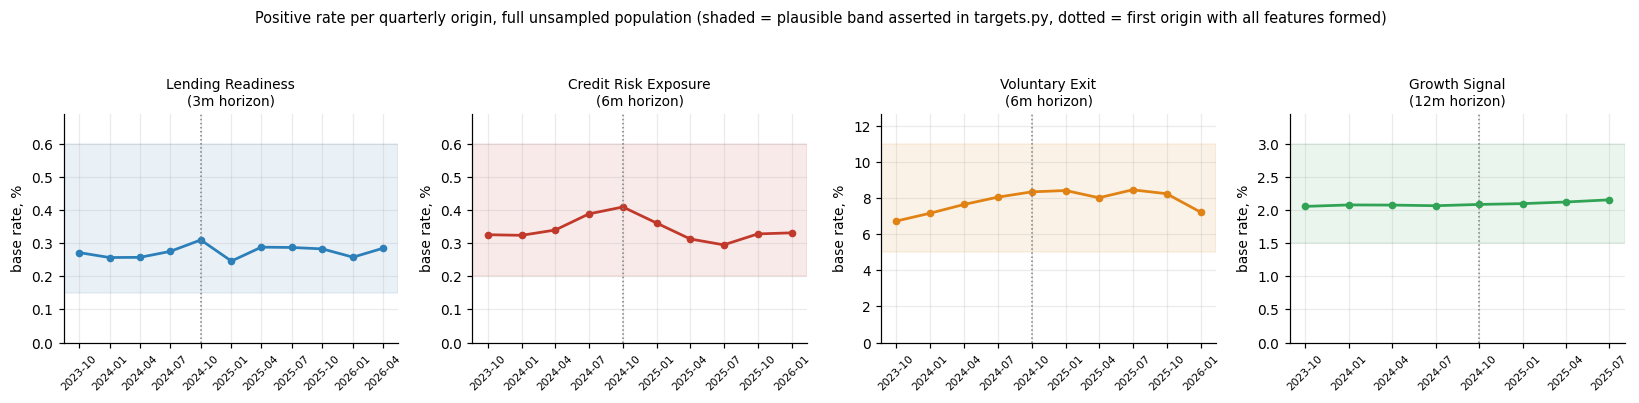

In [7]:
rates = targets.base_rates()
pivot = rates.pivot(index="origin_month", columns="target", values="base_rate")

fig, axes = plt.subplots(1, 4, figsize=(15, 3.4))
for ax, t in zip(axes, ORDER):
    s = pivot[t].dropna() * 100
    lo, hi = [b * 100 for b in targets.EXPECTED_BASE_RATES[t]]
    ax.axhspan(lo, hi, color=COLOR[t], alpha=0.10)
    ax.plot(s.index, s.values, "o-", color=COLOR[t], lw=1.8, ms=4)
    ax.axvline(targets.FIRST_FULL_ORIGIN, color="grey", ls=":", lw=1)
    ax.set_title(f"{NICE[t]}\n({targets.TARGETS[t][1]}m horizon)", fontsize=9)
    ax.set_ylabel("base rate, %")
    ax.set_ylim(0, max(hi, s.max()) * 1.15)
    ax.tick_params(axis="x", rotation=45, labelsize=7)

fig.suptitle("Positive rate per quarterly origin, full unsampled population "
             "(shaded = plausible band asserted in targets.py, dotted = first origin with all features formed)",
             y=1.06, fontsize=9.5)
fig.tight_layout()
plt.show()

Flat, all four of them, inside the bands I wrote down before measuring. Lending sits between 0.25%
and 0.31% across eleven origins with no trend at all, insolvency wanders between 0.29% and 0.41%,
and growth creeps from 2.05% to 2.15% over two years, which is nothing. There is no regime change
hiding in this panel, so an out-of-time split is measuring the model and not the calendar.

Two wobbles worth naming rather than glossing over. Voluntary exit climbs from 6.7% to about 8.4%
over 2024 and then drops back to 7.2% at the final origin. The climb looks like a real shift in
Companies House strike-off activity rather than anything about our pipeline, and the drop at the end
is the one point I trust least: its window is the most recent six months of the register and is the
most exposed to the register still catching up. Insolvency peaks at the 2024-10 origin and settles
back, which on roughly 4,000 positives per origin is well within the noise I would expect.

### 1.6 Positives available per origin

Same data, different question: not "what is the rate" but "how many examples do I actually get to
train on". Note the log scale, otherwise voluntary exit flattens the other three into the axis.

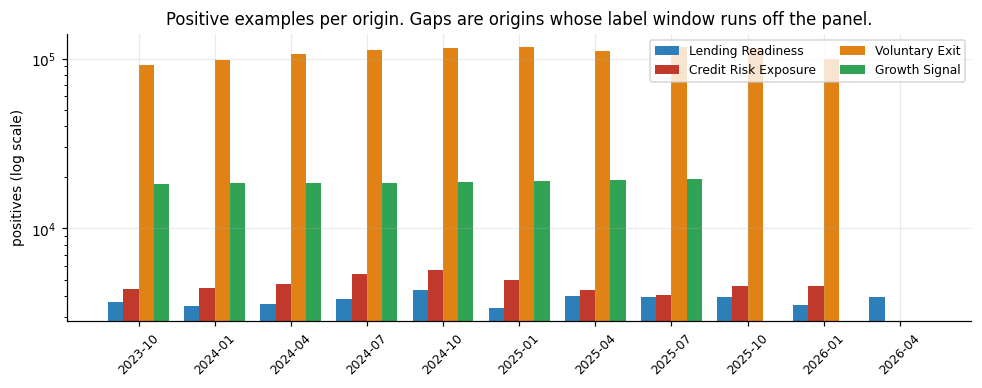

In [8]:
counts = rates.copy()
counts["positives"] = counts["n"] * counts["base_rate"]
cpivot = counts.pivot(index="origin_month", columns="target", values="positives")

fig, ax = plt.subplots(figsize=(9, 3.6))
x = np.arange(len(cpivot.index))
w = 0.2
for i, t in enumerate(ORDER):
    ax.bar(x + (i - 1.5) * w, cpivot[t].fillna(0), w, label=NICE[t], color=COLOR[t])
ax.set_yscale("log")
ax.set_xticks(x)
ax.set_xticklabels([d.strftime("%Y-%m") for d in cpivot.index], rotation=45, fontsize=8)
ax.set_ylabel("positives (log scale)")
ax.set_title("Positive examples per origin. Gaps are origins whose label window runs off the panel.")
ax.legend(fontsize=8, ncol=2)
fig.tight_layout()
plt.show()

The gaps on the right are not missing data, they are the horizon: a 12-month growth label simply
cannot be formed at an origin less than 12 months from the end of the register, so growth runs out
first and lending survives longest. Insolvency is the thin one at around 4,000 positives per origin,
which is a perfectly workable number but it is why I will be watching PR-AUC rather than ROC-AUC
for that target.

### 1.7 Voluntary exit: event versus state, drawn out

Notebook 15 reconciled this in one cell for one origin. Since it is the single most likely question
from anyone reading the report ("your earlier note said 3.5% and now it says 7%"), here it is across
every origin.

**Event** is my label: a strike-off proposal appeared at *any* month in `t+1 ... t+6`.
**State** is what my earlier scoping note measured: the company is *still* sitting in "Proposal to
Strike off" at exactly `t+6`. The gap between the two lines is proposals that were raised and then
withdrawn, which happens routinely once a company files its overdue accounts.

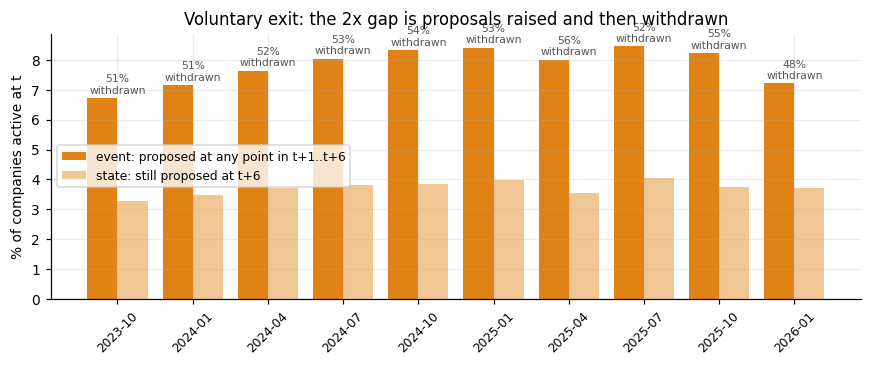

,origin_month,state_at_t6,event_in_window,withdrawn_share
0,2023-10,0.0327,0.0672,0.5132
1,2024-01,0.0349,0.0716,0.5125
2,2024-04,0.0370,0.0764,0.5151
3,2024-07,0.0382,0.0804,0.5252
4,2024-10,0.0384,0.0834,0.5391
5,2025-01,0.0398,0.0841,0.5266
6,2025-04,0.0354,0.0801,0.5579
7,2025-07,0.0404,0.0845,0.5216
8,2025-10,0.0374,0.0824,0.5460
9,2026-01,0.0372,0.0722,0.4848


In [9]:
origins = [m for m in targets.origin_months() if m <= targets.max_origin(6)]
months = sorted({m for m in origins} | {m + pd.DateOffset(months=6) for m in origins})
month_list = ", ".join(f"DATE '{m:%Y-%m-%d}'" for m in months)

state = con.execute(f"""
    WITH s AS (
        SELECT "CompanyNumber" AS cn, snapshot_date AS m,
               lower(trim("CompanyStatus")) AS st
        FROM read_parquet('{DELTA_GLOB}')
        WHERE snapshot_date IN ({month_list})
    )
    SELECT o.m AS origin_month,
           avg((h.st = '{targets.STRIKE_OFF_STATUS}')::INT) AS state_at_t6
    FROM s o
    LEFT JOIN s h ON h.cn = o.cn AND h.m = o.m + INTERVAL 6 MONTH
    WHERE o.st = 'active' AND o.m IN ({", ".join(f"DATE '{m:%Y-%m-%d}'" for m in origins)})
    GROUP BY 1 ORDER BY 1
""").df()

comp = state.merge(
    rates[rates.target == "voluntary_exit"][["origin_month", "base_rate"]]
        .rename(columns={"base_rate": "event_in_window"}),
    on="origin_month", how="inner")
comp["withdrawn_share"] = 1 - comp["state_at_t6"] / comp["event_in_window"]

fig, ax = plt.subplots(figsize=(8, 3.4))
x = np.arange(len(comp))
ax.bar(x - 0.2, comp["event_in_window"] * 100, 0.4, label="event: proposed at any point in t+1..t+6",
       color=COLOR["voluntary_exit"])
ax.bar(x + 0.2, comp["state_at_t6"] * 100, 0.4, label="state: still proposed at t+6",
       color=COLOR["voluntary_exit"], alpha=0.45)
for i, r in comp.iterrows():
    ax.text(i, r["event_in_window"] * 100 + 0.15, f"{r['withdrawn_share']:.0%}\nwithdrawn",
            ha="center", fontsize=7, color="#555")
ax.set_xticks(x)
ax.set_xticklabels([d.strftime("%Y-%m") for d in comp["origin_month"]], rotation=45, fontsize=8)
ax.set_ylabel("% of companies active at t")
ax.set_title("Voluntary exit: the 2x gap is proposals raised and then withdrawn")
ax.legend(fontsize=8)
fig.tight_layout()
plt.show()

comp.assign(origin_month=comp["origin_month"].dt.strftime("%Y-%m")).round(4)

Consistently around half of all proposals get withdrawn inside the window, at every origin. So both
numbers were right, they just answered different questions.

### 1.7b The same thing on one company, because "event versus state" is slippery

CHUBB is no use here, since it never went near a strike-off, so this one worked example runs on a
different company. **FLEX DIGITAL AGENCY LIMITED (14787721)** is what the 2x gap looks like from the
inside.

In [10]:
FLEX = "14787721"

flex = con.execute(f"""
    SELECT snapshot_date, "CompanyStatus" AS status, is_active,
           months_in_current_status, accounts_overdue, months_since_last_confstmt
    FROM read_parquet('{DELTA_GLOB}')
    WHERE "CompanyNumber" = '{FLEX}'
      AND snapshot_date BETWEEN DATE '2024-10-01' AND DATE '2025-10-01'
    ORDER BY snapshot_date
""").df()

flex_labels = con.execute(f"""
    SELECT origin_month, y_voluntary_exit, y_insolvency, y_lending
    FROM read_parquet('{LABEL_GLOB}')
    WHERE "CompanyNumber" = '{FLEX}'
      AND origin_month BETWEEN DATE '2024-10-01' AND DATE '2026-01-01'
    ORDER BY origin_month
""").df()

print("FLEX DIGITAL AGENCY LIMITED: proposed in April 2025, withdrawn by July.")
display(flex)
print("\nits labels over the same period:")
flex_labels

FLEX DIGITAL AGENCY LIMITED: proposed in April 2025, withdrawn by July.


,snapshot_date,status,is_active,months_in_current_status,accounts_overdue,months_since_last_confstmt
0,2024-10-01,Active,True,12,False,6
1,2024-11-01,Active,True,13,False,7
2,2024-12-01,Active,True,14,False,8
3,2025-01-01,Active,True,15,False,9
4,2025-02-01,Active,True,16,True,10
5,2025-03-01,Active,True,17,True,11
6,2025-04-01,Active - Proposal to Strike off,False,0,True,12
7,2025-05-01,Active - Proposal to Strike off,False,1,True,13
8,2025-07-01,Active,True,0,True,3
9,2025-08-01,Active,True,1,True,4



its labels over the same period:


,origin_month,y_voluntary_exit,y_insolvency,y_lending
0,2024-10-01,1,0,0
1,2025-01-01,1,0,0
2,2025-07-01,0,0,0
3,2025-10-01,0,0,0
4,2026-01-01,1,0,0


Follow the story down the status column. The confirmation statement goes unfiled and gets steadily
staler, accounts tip overdue in Feb 2025, a strike-off proposal lands in **April 2025**, sits there
in May, and by **July 2025 the company is Active again**. It filed, and the proposal was withdrawn.
You can see the filing itself in `months_since_last_confstmt` dropping from 13 to 3.

Now the two definitions, both measured at the **2025-01 origin**, whose window is Feb to Jul 2025:

- **Event**: was there a proposal at any month in the window? April says yes. **Label = 1.**
- **State**: is it still proposed at exactly `t+6`, July 2025? No, it is Active again. **Label = 0.**

One company, one window, two definitions, opposite answers. Multiply that by the roughly half of all
proposals that get withdrawn and you have the entire 3.5% versus 7.8% gap from the chart above.

**What actually ships, to be completely unambiguous: the event, including proposals later
withdrawn.** `targets.py` computes
`max(status = 'active - proposal to strike off') OVER (RANGE 1 MONTH FOLLOWING TO 6 MONTH FOLLOWING)`,
so any proposal anywhere in the window sets the label to 1 and nothing later can unset it. Not
"still proposed at the end", and not both. There is one label column and it is the event.

Two reasons, and the first is the one that matters:

1. **A withdrawn proposal is still a real event worth knowing about.** A company that went overdue,
   received a strike-off notice and scrambled to file is a company that was in difficulty, and it is
   a company you could still have helped. Defining it away because it recovered would throw out half
   our positives, and specifically the half where intervention was still possible.
2. **A state read off a single month is fragile.** It depends on that one month existing. June 2025
   does not, so a state label at a December 2024 origin would simply be undefined. The event
   definition does not care.

The honest cost is that Voluntary Exit means **"a strike-off process started"**, not "the company
died". Those are different, and the report needs to say so, otherwise somebody reads 8% as 8% of the
book dissolving.

Two more things worth spotting in that label table. FLEX has **no row at all for the 2025-04
origin**, because labels are conditioned on being Active at `t` and in April it was not: it is not a
0, it is not in the population. And it goes positive **again** at the 2026-01 origin, having fallen
into the same trap a second time.

---
## 2. Do the four labels hit the same companies?

This section is the evidence for a design decision that otherwise looks arbitrary: **four separate
models producing four separate indices**, rather than one composite "prospect score".

If the labels were largely the same event wearing different hats, one model would be simpler and
better. If they are close to independent, then a single score would be an average of unrelated
things and would mean nothing to anyone.

I measure it with **lift**: among companies positive on label B, how many times more likely are they
to be positive on label A than a company picked at random. Lift of 1 means the two labels are
independent. Every pair is computed on the rows where **both** labels are non-NULL, so the
comparison is like for like.

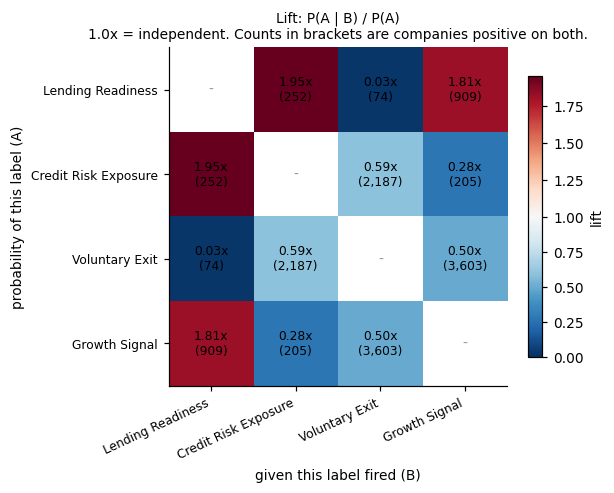

In [11]:
ycols = {t: targets.TARGETS[t][0] for t in ORDER}
pairs = []
for a in ORDER:
    for b in ORDER:
        ca, cb = ycols[a], ycols[b]
        pairs.append(f"""
            SELECT '{a}' AS a, '{b}' AS b,
                   avg({ca}::DOUBLE) AS p_a,
                   avg(CASE WHEN {cb} = 1 THEN {ca}::DOUBLE END) AS p_a_given_b,
                   count(*) FILTER (WHERE {ca} = 1 AND {cb} = 1) AS both
            FROM read_parquet('{LABEL_GLOB}')
            WHERE {ca} IS NOT NULL AND {cb} IS NOT NULL
        """)
ov = con.execute(" UNION ALL ".join(pairs)).df()
ov["lift"] = ov["p_a_given_b"] / ov["p_a"]

lift = ov.pivot(index="a", columns="b", values="lift").loc[ORDER, ORDER]
both = ov.pivot(index="a", columns="b", values="both").loc[ORDER, ORDER]

fig, ax = plt.subplots(figsize=(5.6, 4.6))
m = lift.values.astype(float)
norm = TwoSlopeNorm(vmin=0, vcenter=1, vmax=np.nanmax(np.where(np.eye(4, dtype=bool), np.nan, m)))
im = ax.imshow(np.where(np.eye(4, dtype=bool), np.nan, m), cmap="RdBu_r", norm=norm)
for i in range(4):
    for j in range(4):
        if i == j:
            ax.text(j, i, "-", ha="center", va="center", color="#999")
        else:
            ax.text(j, i, f"{m[i, j]:.2f}x\n({int(both.values[i, j]):,})",
                    ha="center", va="center", fontsize=8)
ax.set_xticks(range(4)); ax.set_xticklabels([NICE[t] for t in ORDER], rotation=25, ha="right", fontsize=8)
ax.set_yticks(range(4)); ax.set_yticklabels([NICE[t] for t in ORDER], fontsize=8)
ax.set_xlabel("given this label fired (B)"); ax.set_ylabel("probability of this label (A)")
ax.set_title("Lift: P(A | B) / P(A)\n1.0x = independent. Counts in brackets are companies positive on both.",
             fontsize=9)
ax.grid(False)
fig.colorbar(im, ax=ax, shrink=0.8, label="lift")
fig.tight_layout()
plt.show()

Read the off-diagonal and the case makes itself. Every pair is informative and **not one of them is
close to being the same label**:

- **Insolvency and voluntary exit are 0.59x, not 1.0x and nowhere near it.** They are both "the
  company stops being a normal active company", they share a six-month horizon, and a company that
  proposes a strike-off is *less* likely than average to enter genuine insolvency. This is the pair I
  most needed to check, because the original plan merged them into one "non-Active by t+H" label.
  Merging them would have produced a risk model that was about 90% dormant micro-companies quietly
  closing, and this cell is the proof.
- **Lending goes with insolvency (1.95x) and with growth (1.81x), and is almost mutually exclusive
  with voluntary exit (0.03x).** That last number is the striking one: only 74 companies in the whole
  panel took on a new charge and proposed to strike themselves off in the same window. It is
  economically obvious once you say it out loud (nobody lends to a company that is closing, and
  nobody closes a company they just borrowed against) but it is a strong validation that both labels
  are measuring what they claim to.
- **Borrowing precedes both good and bad outcomes.** Lending at 1.95x with insolvency is worth sitting
  with: taking on debt is a leading indicator of both growth and failure. That is a real finding for
  the report and it is an argument for showing Lending Readiness and Credit Risk Exposure side by
  side rather than netting them off into one number.
- **Growth and insolvency are 0.28x**, which is the sanity check I expected: growing companies do not
  fail, at least not within a year.

None of these pairs are substitutes for one another. Four indices it is.

### 2.1 How many companies carry more than one signal at once

The same point from the company's side rather than the label's. Restricted to a single origin
(2025-01) with all four labels non-NULL, so every company in the count was eligible for all four.

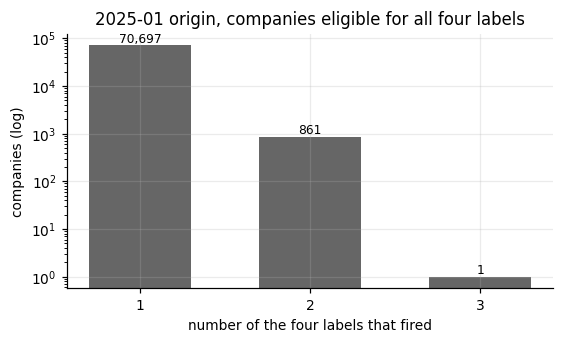

,n_labels,companies,share_%
0,0,835396,92.110
1,1,70697,7.795
2,2,861,0.095
3,3,1,0.000


In [12]:
multi = con.execute(f"""
    SELECT n_labels, count(*) AS companies
    FROM (
        SELECT y_lending + y_insolvency + y_voluntary_exit + y_growth AS n_labels
        FROM read_parquet('{LABEL_GLOB}')
        WHERE origin_month = DATE '2025-01-01'
          AND y_lending IS NOT NULL AND y_insolvency IS NOT NULL
          AND y_voluntary_exit IS NOT NULL AND y_growth IS NOT NULL
    )
    GROUP BY 1 ORDER BY 1
""").df()
multi["share_%"] = (100 * multi["companies"] / multi["companies"].sum()).round(3)

pos = multi[multi.n_labels > 0]
fig, ax = plt.subplots(figsize=(5.2, 3.2))
ax.bar(pos["n_labels"], pos["companies"], color="#666", width=0.6)
for _, r in pos.iterrows():
    ax.text(r.n_labels, r.companies, f"{int(r.companies):,}", ha="center", va="bottom", fontsize=8)
ax.set_yscale("log")
ax.set_xticks(pos["n_labels"])
ax.set_xlabel("number of the four labels that fired")
ax.set_ylabel("companies (log)")
ax.set_title("2025-01 origin, companies eligible for all four labels")
fig.tight_layout()
plt.show()

multi

At the 2025-01 origin, 92.1% of eligible companies fire on nothing at all, 7.8% fire on exactly one
label, 861 companies fire on two, and precisely one company managed three. So the four indices carve
up the book into almost disjoint groups rather than re-ranking the same few thousand companies four
times. A company that trips two at once is rare enough to be worth surfacing on its own in the final
output.

---
## 3. Which features separate positives from negatives

This is a preview of step 6's SHAP plots, computed without a model. For each feature I take the
**univariate AUC**: rank every company by that one feature and ask how often a positive ranks above a
negative. 0.50 is a coin flip and carries no information; the further from 0.50 in either direction,
the more that single column already knows.

Two notes on method, because both would be fair challenges:

- This runs on `model_matrix/`, where negatives are downsampled 1:10. **AUC is a ranking statistic
  and is unaffected in expectation by dropping a random subset of negatives**, so it transfers. Rates
  and counts would not, which is why they are not in this section.
- NULLs are dropped per feature rather than imputed. LightGBM handles missingness natively in step 6,
  so imputing here to get a number would be inventing data the model will never see.

In [13]:
FEATS = [c for c in targets.FEATURE_COLS if c not in targets.CATEGORICAL_COLS]
SAMPLE_N = 400_000


def load_sample(target):
    """Read the target's matrix, capped at SAMPLE_N rows via a hash on the company number."""
    cols = ", ".join(f'"{c}"' for c in FEATS)
    n = con.execute(f"SELECT count(*) FROM read_parquet('{MATRIX(target)}')").fetchone()[0]
    keep = min(1.0, SAMPLE_N / n)
    df = con.execute(f"""
        SELECT y, {cols}
        FROM read_parquet('{MATRIX(target)}')
        WHERE origin_month >= DATE '{targets.FIRST_FULL_ORIGIN:%Y-%m-%d}'
          AND (hash("CompanyNumber") % 1000000) / 1000000.0 < {keep}
    """).df()
    return n, df


def auc_vs_y(x, y):
    """Mann-Whitney AUC with tie-aware average ranks. NaNs dropped."""
    ok = ~pd.isna(x)
    x, y = np.asarray(x[ok], dtype=float), np.asarray(y[ok], dtype=int)
    n_pos, n_neg = y.sum(), (1 - y).sum()
    if n_pos == 0 or n_neg == 0:
        return np.nan
    r = pd.Series(x).rank(method="average").values
    return (r[y == 1].sum() - n_pos * (n_pos + 1) / 2) / (n_pos * n_neg)


auc = {}
for t in ORDER:
    n_rows, df = load_sample(t)
    y = df["y"].values
    auc[t] = pd.Series({f: auc_vs_y(df[f].astype(float) if df[f].dtype != bool else df[f].astype(float), y)
                        for f in FEATS})
    print(f"{t:15s} matrix {n_rows:>10,} rows -> sampled {len(df):>8,}  ({y.mean():.1%} positive after downsampling)")

auc = pd.DataFrame(auc)[ORDER]

lending         matrix    457,941 rows -> sampled  259,888  (9.1% positive after downsampling)


insolvency      matrix    520,142 rows -> sampled  238,872  (9.1% positive after downsampling)


voluntary_exit  matrix 11,917,730 rows -> sampled  247,417  (9.0% positive after downsampling)


growth          matrix  1,657,611 rows -> sampled  203,636  (9.0% positive after downsampling)


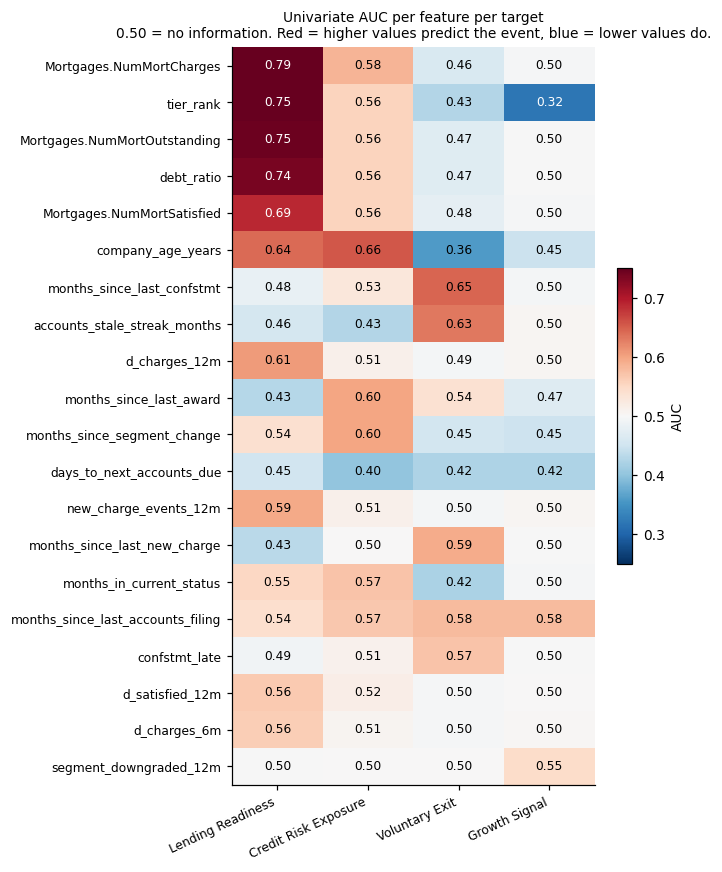

In [14]:
# Rank features by how far any target pushes them away from a coin flip.
strength = (auc - 0.5).abs().max(axis=1).sort_values(ascending=False)
top = auc.loc[strength.head(20).index]

fig, ax = plt.subplots(figsize=(6.4, 8))
m = top.values
im = ax.imshow(m, cmap="RdBu_r", norm=TwoSlopeNorm(vmin=0.25, vcenter=0.5, vmax=0.75), aspect="auto")
for i in range(m.shape[0]):
    for j in range(m.shape[1]):
        v = m[i, j]
        ax.text(j, i, "n/a" if np.isnan(v) else f"{v:.2f}", ha="center", va="center", fontsize=8,
                color="white" if not np.isnan(v) and abs(v - 0.5) > 0.17 else "black")
ax.set_xticks(range(4)); ax.set_xticklabels([NICE[t] for t in ORDER], rotation=25, ha="right", fontsize=8)
ax.set_yticks(range(len(top))); ax.set_yticklabels(top.index, fontsize=8)
ax.set_title("Univariate AUC per feature per target\n"
             "0.50 = no information. Red = higher values predict the event, blue = lower values do.",
             fontsize=9)
ax.grid(False)
fig.colorbar(im, ax=ax, shrink=0.4, label="AUC")
fig.tight_layout()
plt.show()

In [15]:
# The full table, since the heatmap only shows the top 20 of 39.
auc.round(3).sort_values("lending", ascending=False)

,lending,insolvency,voluntary_exit,growth
Mortgages.NumMortCharges,0.791,0.585,0.461,0.498
tier_rank,0.753,0.556,0.427,0.319
Mortgages.NumMortOutstanding,0.746,0.556,0.470,0.499
debt_ratio,0.738,0.556,0.471,0.499
Mortgages.NumMortSatisfied,0.688,0.555,0.478,0.497
company_age_years,0.642,0.656,0.358,0.446
d_charges_12m,0.606,0.513,0.495,0.505
new_charge_events_12m,0.594,0.513,0.496,0.505
d_satisfied_12m,0.564,0.516,0.497,0.501
d_charges_6m,0.562,0.507,0.497,0.502


This is the most useful single thing in the notebook, and it says four different stories:

- **Lending is a size-and-existing-debt story, and it is by far the easiest of the four.**
  `Mortgages.NumMortCharges` alone gets 0.79, with `tier_rank` at 0.75, `NumMortOutstanding` at 0.75
  and `debt_ratio` at 0.74. Companies that already carry charges take on more. That is honest, but it
  means the raw ranking will be large leveraged companies first, and an SME desk will need the
  ranking done **within** a size band. I would rather know that now than after someone has worked the
  list.
- **Voluntary exit is a filing-behaviour story**, and this is where notebook 12's exclusion list
  would have hurt us. Sneha correctly dropped the filing features from her cross-sectional model
  because a company that has stopped filing is *already* in trouble, so they leak the answer. In a
  panel they become leading indicators instead: `months_since_last_confstmt` at 0.65 and
  `accounts_stale_streak_months` at 0.63, measured at `t` and predicting a proposal at `t+6`. That
  inversion is one of the clearest arguments for having built a time series at all.
- **Insolvency is the hard one, and it is not the same story as voluntary exit.** Its best single
  feature is `company_age_years` at 0.66, and the filing features that dominate voluntary exit sit
  at or below 0.43 for it. Nothing reaches 0.7. This is the target where I expect the model to earn
  its keep by combining weak signals, and the one where I will read PR-AUC rather than ROC-AUC.
- **Growth is dominated by `tier_rank` at 0.32**, and the direction matters: *low* rank predicts an
  upgrade. That is a ceiling effect, not signal. A Large company cannot be upgraded, so the label is
  mechanically impossible at the top of the ladder. Apart from that, nothing beats 0.58. Step 6 needs
  to check hard whether the growth model is learning growth or learning "is not already Large".

No feature is anywhere near 0.9, which is exactly what I want to see. A single column at 0.95 would
mean leakage, and notebook 15 already asserted the strongest correlation with `y` is 0.37.

### 3.1 Response curves for the top feature of each target

AUC says a feature ranks well. It does not say what shape the relationship has, and shape is what
you can actually explain to someone. So: bin the feature, and plot the true positive rate in each bin.

"True" is doing work in that sentence. These come from the downsampled matrix, so the raw rates are
inflated by roughly 11x. I undo the sampling with the `neg_keep_rate` column that notebook 15
deliberately carried through, using the same identity step 6 will use to recalibrate its predicted
probabilities:

`p_true = p_sampled * w / (1 - p_sampled + p_sampled * w)`, where `w` is the negative keep rate.

I run it on the 2025-01 origin only, where `w` is a single number per target rather than a mix.

top univariate feature per target: {'lending': 'Mortgages.NumMortCharges', 'insolvency': 'company_age_years', 'voluntary_exit': 'months_since_last_confstmt', 'growth': 'tier_rank'}


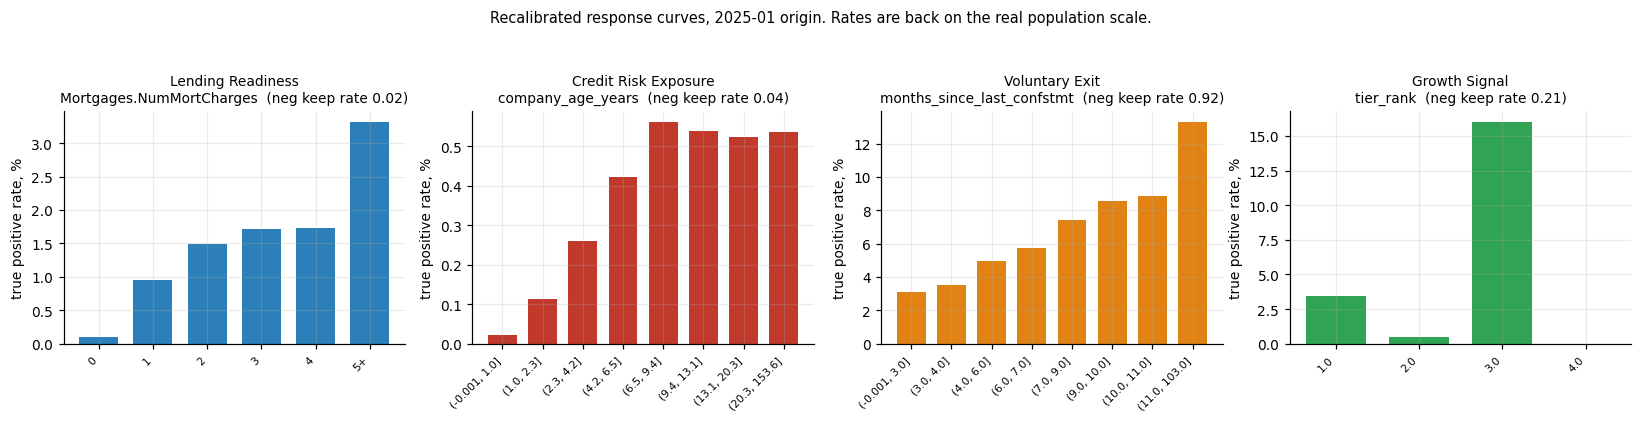

In [16]:
def response_curve(target, feature, origin="2025-01-01", bins=8):
    df = con.execute(f"""
        SELECT y, neg_keep_rate, "{feature}"::DOUBLE AS x
        FROM read_parquet('{MATRIX(target)}')
        WHERE origin_month = DATE '{origin}' AND "{feature}" IS NOT NULL
    """).df()
    w = df["neg_keep_rate"].iloc[0]
    # Exact values where the feature takes few of them, quantile bins where it is continuous.
    # Skewed counts (most companies at 0) collapse qcut to two or three bins, so fall back to
    # clipped integer buckets there rather than plot a two-bar "curve".
    if df["x"].nunique() <= bins:
        df["bin"] = df["x"]
        labels = sorted(df["x"].unique())
    else:
        q = pd.qcut(df["x"], bins, duplicates="drop")
        if len(q.cat.categories) >= 4:
            df["bin"] = q
            labels = list(q.cat.categories)
        else:
            top = 5
            df["bin"] = np.where(df["x"] >= top, f"{top}+", df["x"].astype(int).astype(str))
            labels = [str(i) for i in range(top)] + [f"{top}+"]
    g = df.groupby("bin", observed=True)["y"].agg(["mean", "size"]).reindex(labels).dropna()
    p_s = g["mean"]
    g["true_rate"] = p_s * w / (1 - p_s + p_s * w)
    return g, w


TOP = {t: auc[t].sub(0.5).abs().idxmax() for t in ORDER}
print("top univariate feature per target:", TOP)

fig, axes = plt.subplots(1, 4, figsize=(15, 3.6))
for ax, t in zip(axes, ORDER):
    g, w = response_curve(t, TOP[t])
    x = np.arange(len(g))
    ax.bar(x, g["true_rate"] * 100, color=COLOR[t], width=0.72)
    ax.set_xticks(x)
    ax.set_xticklabels([str(i) for i in g.index], rotation=45, ha="right", fontsize=7)
    ax.set_title(f"{NICE[t]}\n{TOP[t]}  (neg keep rate {w:.2f})", fontsize=9)
    ax.set_ylabel("true positive rate, %")
fig.suptitle("Recalibrated response curves, 2025-01 origin. Rates are back on the real population scale.",
             y=1.05, fontsize=9.5)
fig.tight_layout()
plt.show()

Three of the four are cleanly monotone. Lending climbs from 0.11% for companies with no charges to
3.3% for those carrying five or more, a **30x spread off a single column**. Insolvency rises steadily
with age, from 0.02% for companies under a year old to about 0.55% past thirteen years. Voluntary
exit goes from 3% to 13% as the confirmation statement gets staler, which is exactly the shape you
would draw by hand.

**Growth is the exception and it is not noise.** Micro to Small runs at 3.5%, Small to Medium at
0.5%, Medium to Large at 16%, and Large at a hard zero because there is nothing above it. That is
the filing thresholds showing through: the Small-to-Medium boundary is a real cliff in Companies
House terms and very few companies cross it, while Medium-to-Large is comparatively easy. Worth
putting in the report as a finding about the size ladder itself, and worth remembering when reading
the growth model's SHAP plot, because a tree will find this shape immediately.

Every level here is back on the real population scale rather than the ~9% the sampled matrix would
have shown me. That matters more than it looks: if I had plotted the raw sampled rate, every number
on this figure would have been about eleven times too large, and it is exactly the sort of mistake
that survives into a slide and gets quoted at a client.

---
## 4. Who the positives are

The section a relationship manager reads first. Which parts of the book carry each signal?

All of this comes from `labels/` joined back to the panel at the origin month, so these are **true
unsampled rates**. I pool every origin from `FIRST_FULL_ORIGIN` (2024-10) onwards, which is where all
the features are properly formed, and it also gives the thin insolvency label enough positives per
cell to be worth plotting.

Each figure is a **lift** heatmap: the cell's base rate divided by that target's overall base rate,
with the underlying rate printed inside. 1.0x is "behaves like the average company".

### How to read a cell, since "positive" is doing a lot of work here

The unit being counted is a **company-origin row**, not a company. A company observed at five
quarterly origins contributes five rows, and each one is separately positive or negative. Pooling
2024-10 onwards, that is 11.1 million rows.

A **positive** is a row where that target's label fired inside its own window. Not a company that
looks risky, not a company that is currently struggling. It is a company for which, standing in that
month, the thing then happened within the horizon.

So the top-left-ish cell `Large / Lending Readiness / 2.74% / 9.8x` reads as:

> of all the times a Large company was observed at a quarterly origin, 2.74% of those times it took
> on a new charge within the following three months, which is 9.8 times the rate across the whole
> book.

It does **not** mean 9.8% of large companies, and it does not mean 2.74% of large companies ever
borrow. Getting that wrong in either direction is the easiest mistake to make with this figure, and
the reason I have written the sentence out longhand.

One consequence worth stating: because these are rates over rows rather than counts, a bucket with
a huge lift can still be a small number of actual companies. The row labels carry the bucket size in
brackets so you can see which cells are worth acting on.

In [17]:
CUTS = {
    "sector": 'p.sector',
    "size band": "coalesce(p.size_tier, 'no size band')",
    "company age": """CASE WHEN p.company_age_years < 2 THEN 'a. under 2y'
                          WHEN p.company_age_years < 5 THEN 'b. 2-5y'
                          WHEN p.company_age_years < 10 THEN 'c. 5-10y'
                          WHEN p.company_age_years < 20 THEN 'd. 10-20y'
                          ELSE 'e. 20y+' END""",
    "postcode area": """regexp_extract(upper(trim(p."RegAddress.PostCode")), '^[A-Z]{1,2}')""",
}

SEL = ",\n           ".join(
    f'avg(l.{col}::DOUBLE) AS "{t}", count(l.{col}) AS "n_{t}"'
    for t, (col, _) in targets.TARGETS.items())


def cut_rates(expr):
    return con.execute(f"""
        SELECT {expr} AS bucket,
               count(*) AS companies,
               {SEL}
        FROM read_parquet('{LABEL_GLOB}') l
        JOIN read_parquet('{DELTA_GLOB}') p
          ON p."CompanyNumber" = l."CompanyNumber" AND p.snapshot_date = l.origin_month
        WHERE l.origin_month >= DATE '{targets.FIRST_FULL_ORIGIN:%Y-%m-%d}'
        GROUP BY 1
    """).df()


cuts = {name: cut_rates(expr) for name, expr in CUTS.items()}
for name, df in cuts.items():
    print(f"{name:14s} {len(df):>3} buckets, {int(df['companies'].sum()):,} company-origin rows")

sector           4 buckets, 11,136,951 company-origin rows
size band        5 buckets, 11,136,951 company-origin rows
company age      5 buckets, 11,136,951 company-origin rows
postcode area  186 buckets, 11,136,951 company-origin rows


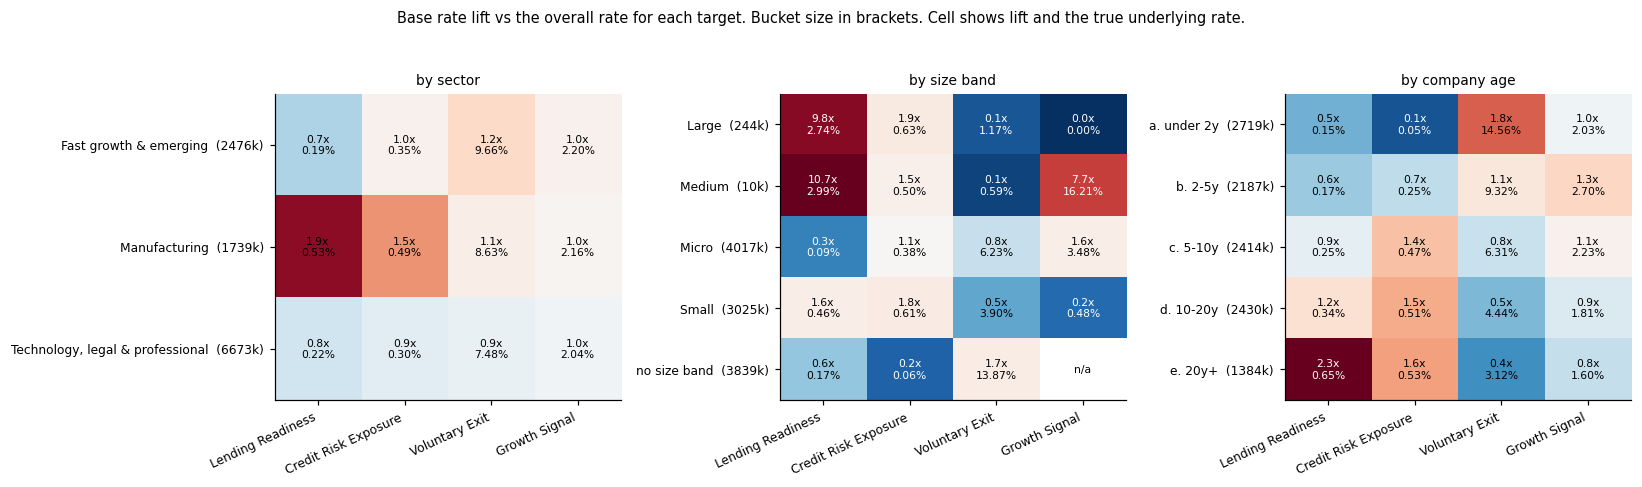

overall pooled base rates: {'lending': '0.279%', 'insolvency': '0.339%', 'voluntary_exit': '8.110%', 'growth': '2.114%'}


In [18]:
def lift_heatmap(ax, df, name, min_companies=5000, top_n=None):
    d = df[df["companies"] >= min_companies].copy()
    d = d.dropna(subset=["bucket"])
    if top_n:
        d = d.nlargest(top_n, "companies")
    d = d.sort_values("bucket" if name != "postcode area" else "companies",
                      ascending=name != "postcode area")

    overall = {t: np.average(df[t].dropna(),
                             weights=df.loc[df[t].notna(), f"n_{t}"]) for t in ORDER}
    rate = d[ORDER].astype(float)
    lift = rate / pd.Series(overall)

    m = lift.values
    im = ax.imshow(m, cmap="RdBu_r", norm=TwoSlopeNorm(vmin=0, vcenter=1, vmax=max(2.0, np.nanmax(m))),
                   aspect="auto")
    for i in range(m.shape[0]):
        for j in range(m.shape[1]):
            txt = ("n/a" if np.isnan(m[i, j])
                   else f"{m[i, j]:.1f}x\n{rate.values[i, j] * 100:.2f}%")
            ax.text(j, i, txt, ha="center", va="center", fontsize=7,
                    color="white" if m[i, j] > 2.2 or m[i, j] < 0.35 else "black")
    ax.set_xticks(range(4)); ax.set_xticklabels([NICE[t] for t in ORDER], rotation=25, ha="right", fontsize=8)
    ax.set_yticks(range(len(d)))
    ax.set_yticklabels([f"{b}  ({int(n / 1000)}k)" for b, n in zip(d["bucket"], d["companies"])], fontsize=8)
    ax.set_title(f"by {name}", fontsize=9)
    ax.grid(False)
    return overall


fig, axes = plt.subplots(1, 3, figsize=(15, 4.2))
for ax, name in zip(axes, ["sector", "size band", "company age"]):
    overall = lift_heatmap(ax, cuts[name], name)
fig.suptitle("Base rate lift vs the overall rate for each target. Bucket size in brackets. "
             "Cell shows lift and the true underlying rate.", y=1.04, fontsize=9.5)
fig.tight_layout()
plt.show()

print("overall pooled base rates:", {k: f"{v:.3%}" for k, v in overall.items()})

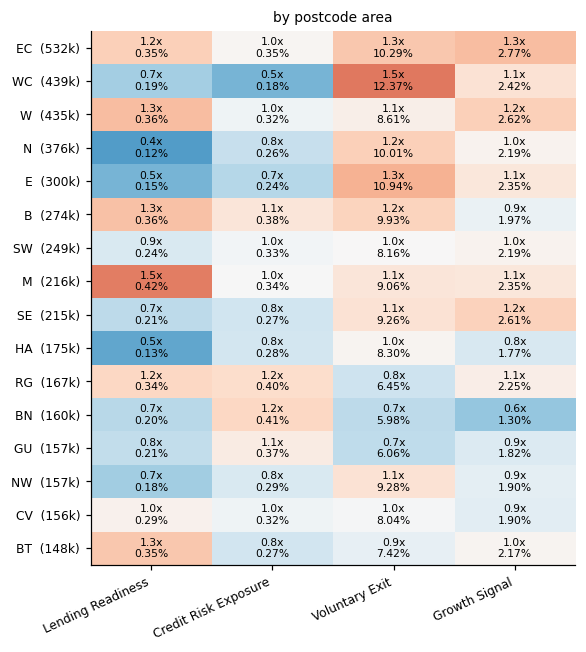

In [19]:
fig, ax = plt.subplots(figsize=(5.4, 6))
lift_heatmap(ax, cuts["postcode area"], "postcode area", min_companies=20000, top_n=16)
fig.tight_layout()
plt.show()

What I take from these four figures, in the order I would put them in the report:

**Size is by far the strongest cut, and it points in opposite directions for different indices.**
Lending readiness runs 0.09% for Micro companies against 2.74% for Large, a **30x spread**, while
voluntary exit goes the other way (13.9% for companies with no size band at all, 1.2% for Large).
Growth is 16.2% for Medium and a structural 0.0% for Large. So a naive "top 500 by lending score"
list will be entirely large companies, and the SME desk needs the ranking done **within** a size
band, not across all of them. I would much rather find that here than after someone has worked the
list.

**Company age separates the two failure modes cleanly, and in opposite directions.** Voluntary exit
is a young-company phenomenon: 14.6% for companies under two years old, falling to 3.1% past twenty.
Genuine insolvency does the reverse, 0.05% under two years and rising to about 0.5% for companies
over ten. That is the difference between a dormant shell being abandoned and an established trading
business failing, and it is more evidence that merging the two labels would have been a mistake.

**Sector matters less than I expected, with one exception.** Manufacturing carries 1.9x the lending
rate and 1.5x the insolvency rate of the book as a whole; the other two sectors sit within about
20% of average on every index. So sector is not going to be a headline driver, and I would check
whether even the manufacturing effect survives controlling for size, because manufacturers skew
larger.

**Geography is real but modest.** The spread across postcode areas is roughly 0.4x to 1.5x on
lending, against 30x for size. It is worth a slide, not a chapter, and I would not build a regional
targeting story on it without a lot more care about where registered offices actually sit, since
plenty of them are the company's accountant rather than the business.

---
## Where this leaves the report

The figures I would actually use, in order:

1. **1.5, base-rate stability.** Justifies the whole out-of-time evaluation plan in one picture.
2. **2, the lift matrix.** The reason there are four indices and not one score. This is the design
   decision most likely to be challenged and this figure settles it.
3. **1.7, event versus state.** Pre-empts the "your numbers changed" question about voluntary exit.
4. **3, univariate AUC.** Sets expectations for the SHAP plots before anyone has seen a model, and
   makes the point that our features are informative without being leaky.
5. **4, the lift heatmaps.** The business-facing cut, and the source of the size-band warning that
   actually changes how the shortlist should be built.

Nothing here changed a label. It did change how I plan to read step 6:

- **Rank lending within size band.** A 30x size gradient means the unconditioned top-N is a list of
  large companies, which is not what an SME desk asked for.
- **Read PR-AUC, not ROC-AUC, for insolvency.** Best single feature 0.66, 0.34% base rate, roughly
  4,000 positives per origin. ROC-AUC will look respectable on that no matter what.
- **Interrogate the growth model.** Its strongest feature is an inverted `tier_rank`, which is a
  ceiling effect. If SHAP comes back saying "small companies grow", that is the label's arithmetic
  talking, not a finding.
- **Expect the filing features to carry voluntary exit**, and expect them to be nearly useless for
  insolvency. If the SHAP plots disagree with that, something has gone wrong between here and there.